# New Notebook

Run a cell with **Shift+Enter** (moves to next) or **Ctrl+Enter** (stays).
Double-click rendered markdown to edit it. Save with **Ctrl+S**.

In [ ]:
# 1. Basic Python
print("Hello from the Notebook!")

nums = [1, 2, 3, 4, 5]
print("Sum:", sum(nums))
print("Squares:", [x**2 for x in nums])

Hello from the Notebook!
Sum: 15
Squares: [1, 4, 9, 16, 25]


## Matplotlib

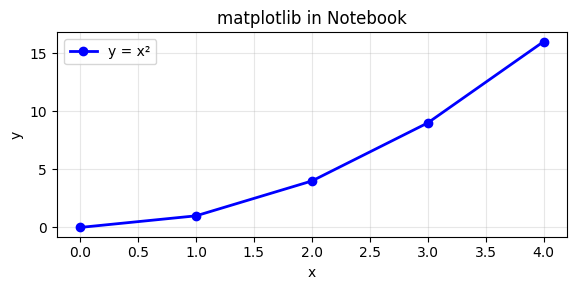

In [ ]:
# 2. Matplotlib — install once per session, then import freely
import micropip
await micropip.install('matplotlib')   # top-level await works in any cell

import matplotlib.pyplot as plt

x = [0, 1, 2, 3, 4]
y = [0, 1, 4, 9, 16]
plt.figure(figsize=(6, 3))
plt.plot(x, y, 'b-o', linewidth=2, label='y = x²')
plt.title('matplotlib in Notebook')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()   # optional — open figures auto-render after each cell

## Images

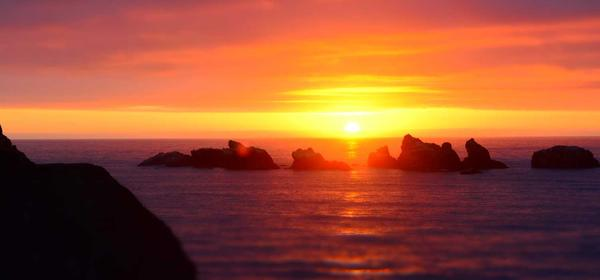


Fetched from https://picsum.photos/seed/notebook/600/280


In [ ]:
# 3. Image from URL — fetch with the browser's JS fetch API
from js import fetch
import base64

url = 'https://picsum.photos/seed/notebook/600/280'
response = await fetch(url)
buffer   = await response.arrayBuffer()
b64      = base64.b64encode(bytes(buffer.to_py())).decode()

# <nb-img> tags in stdout are rendered as inline images
print(f'<nb-img>{b64}</nb-img>')
print(f'Fetched from {url}')

Saved 38 KB to /home/user1/sample-image.b64


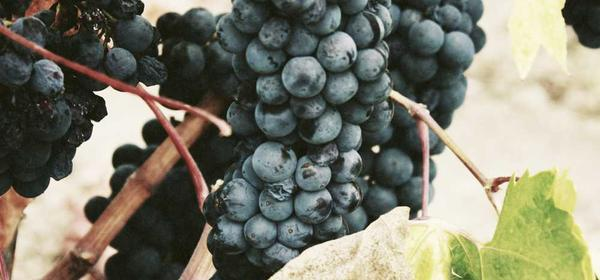


Loaded and displayed from VFS


In [ ]:
# 4. Image from VFS — download, save to VFS, then load back
from js import fetch, window
import base64

bridge   = window.__nbBridge
VFS_PATH = '/home/user1/sample-image.b64'

# Download and save (base64-encoded) to VFS
url      = 'https://picsum.photos/seed/vfs/600/280'
response = await fetch(url)
buffer   = await response.arrayBuffer()
b64      = base64.b64encode(bytes(buffer.to_py())).decode()
bridge.writeFile(VFS_PATH, b64)
print(f'Saved {len(b64)//1024} KB to {VFS_PATH}')

# Load back from VFS and display
stored = str(bridge.readFile(VFS_PATH))
print(f'<nb-img>{stored}</nb-img>')
print(f'Loaded and displayed from VFS')

## Pandas / CSV

In [ ]:
# 5. Load and save CSV in VFS using pandas
import micropip
await micropip.install('pandas')

import pandas as pd
import io
from js import window

bridge   = window.__nbBridge
CSV_PATH = '/home/user1/cities.csv'

# Create a sample DataFrame
df = pd.DataFrame({
    'city':         ['New York', 'London', 'Tokyo', 'Paris',  'Sydney'],
    'temp_c':       [22,         18,       29,      20,       17],
    'humidity_pct': [65,         72,       80,      68,       60],
    'rainy_days':   [121,        164,      107,     111,      140],
})

# Save to VFS
bridge.writeFile(CSV_PATH, df.to_csv(index=False))
print(f'Saved {len(df)} rows to {CSV_PATH}\n')

# Load back from VFS
raw = str(bridge.readFile(CSV_PATH))
df2 = pd.read_csv(io.StringIO(raw))

print('Loaded from VFS:')
print(df2.to_string(index=False))
print()
print('Statistics:')
print(df2.describe().round(1).to_string())

<exec>:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
Saved 5 rows to /home/user1/cities.csv

Loaded from VFS:
    city  temp_c  humidity_pct  rainy_days
New York      22            65         121
  London      18            72         164
   Tokyo      29            80         107
   Paris      20            68         111
  Sydney      17            60         140

Statistics:
       temp_c  humidity_pct  rainy_days
count     5.0           5.0         5.0
mean     21.2          69.0       128.6
std       4.8           7.5        23.5
min      17.0          60.0       107.0
25%      18.0          65.0       111.0
50%